In [16]:
from langgraph. graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [28]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=0.7
)

In [29]:
class LLMState(TypedDict):
    question: str
    answer: str

In [36]:
def llm_node(state: LLMState) -> LLMState:
    question = state['question']
    prompt = f'answer the following question: {question}'
    answer = llm.invoke(prompt).content
    state['answer'] = answer
    return state

In [37]:
graph = StateGraph(LLMState)
graph.add_node('llm_node',llm_node)
graph.add_edge(START, 'llm_node')
graph.add_edge('llm_node', END)


In [38]:
workflow = graph.compile()

In [39]:
print(workflow.invoke({'question': 'What is the capital of France?'})['answer'])

The capital of France is **Paris**.


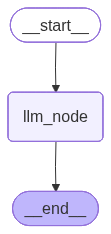

In [40]:
from IPython.display import Image
Image (workflow.get_graph().draw_mermaid_png())